In [1]:
from sklearn.datasets import load_diabetes

In [2]:
dataset=load_diabetes()

In [3]:
import pandas as pd
df_diabetes=pd.DataFrame(dataset.data,columns=['age',
  'sex',
  'bmi',
  'bp',
  's1',
  's2',
  's3',
  's4',
  's5',
  's6'])
df_diabetes.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [4]:
## Independent and dependent features
X=df_diabetes
y=dataset['target']

In [5]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=10)

<Axes: >

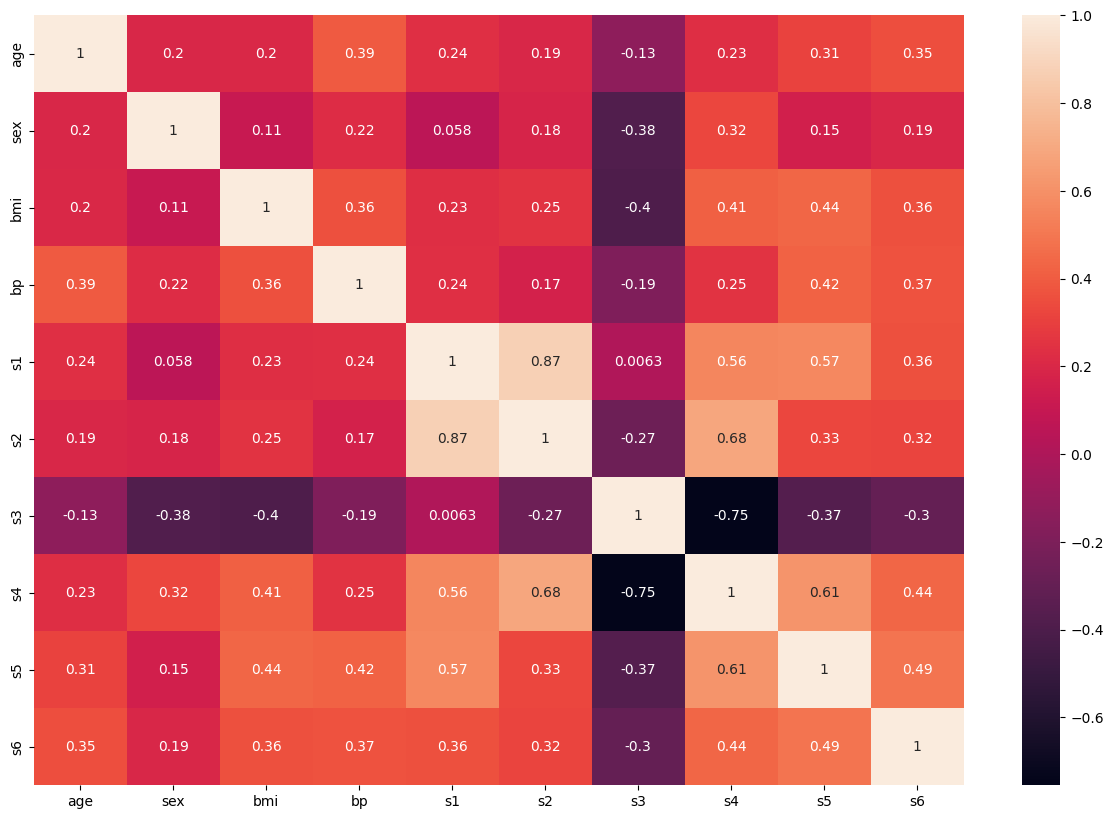

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(15,10))
sns.heatmap(X_train.corr(),annot=True)

In [7]:
from sklearn.tree import DecisionTreeRegressor
regressor=DecisionTreeRegressor()
regressor.fit(X_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [8]:
param={
    'criterion':['squared_error','friedman_mse','absolute_error'],
    'splitter':['best','random'],
    'max_depth':[1,2,3,4,5,10,15,20,25],
    'max_features':['auto','sqrt','log2']
}

In [9]:
from sklearn.model_selection import GridSearchCV

In [10]:
regressor=DecisionTreeRegressor()

In [11]:
grid=GridSearchCV(regressor,param_grid=param,cv=5,scoring='neg_mean_squared_error')

In [12]:
grid.fit(X_train,y_train)

c:\Users\ravin\anaconda3\envs\ml_env\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
270 fits failed out of a total of 810.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
270 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\ravin\anaconda3\envs\ml_env\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\ravin\anaconda3\envs\ml_env\lib\site-packages\sklearn\base.py", line 1358, in wrapper
    estimator._validate_params()
  File "c:\Users\ravin\anaconda3\envs\ml_env\lib\site-packages\sklearn\base.py", line 471, in _validate_params
    validate_parameter_constraints(


,estimator,DecisionTreeRegressor()
,param_grid,"{'criterion': ['squared_error', 'friedman_mse', ...], 'max_depth': [1, 2, ...], 'max_features': ['auto', 'sqrt', ...], 'splitter': ['best', 'random']}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'squared_error'


In [13]:
y_pred=grid.predict(X_test)

In [14]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [15]:
print(r2_score(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))

0.40906011444719725
49.394763606316786
3739.273232713285


In [16]:
selectedmodel=DecisionTreeRegressor(criterion='friedman_mse',max_depth=4,max_features='log2',splitter='random')

In [17]:
selectedmodel.fit(X_train,y_train)

,criterion,'friedman_mse'
,splitter,'random'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


[Text(0.5, 0.9, 'x[8] <= -0.055\nfriedman_mse = 5757.456\nsamples = 309\nvalue = 152.738'),
 Text(0.25, 0.7, 'x[4] <= -0.043\nfriedman_mse = 1957.358\nsamples = 35\nvalue = 93.314'),
 Text(0.375, 0.8, 'True  '),
 Text(0.125, 0.5, 'x[8] <= -0.063\nfriedman_mse = 1988.127\nsamples = 18\nvalue = 97.389'),
 Text(0.0625, 0.3, 'x[2] <= -0.055\nfriedman_mse = 2125.801\nsamples = 14\nvalue = 101.643'),
 Text(0.03125, 0.1, 'friedman_mse = 509.25\nsamples = 4\nvalue = 81.5'),
 Text(0.09375, 0.1, 'friedman_mse = 2545.21\nsamples = 10\nvalue = 109.7'),
 Text(0.1875, 0.3, 'x[5] <= -0.074\nfriedman_mse = 1221.25\nsamples = 4\nvalue = 82.5'),
 Text(0.15625, 0.1, 'friedman_mse = 0.0\nsamples = 1\nvalue = 37.0'),
 Text(0.21875, 0.1, 'friedman_mse = 708.222\nsamples = 3\nvalue = 97.667'),
 Text(0.375, 0.5, 'x[0] <= 0.021\nfriedman_mse = 1888.588\nsamples = 17\nvalue = 89.0'),
 Text(0.3125, 0.3, 'x[2] <= -0.031\nfriedman_mse = 1615.168\nsamples = 14\nvalue = 84.786'),
 Text(0.28125, 0.1, 'friedman_mse = 

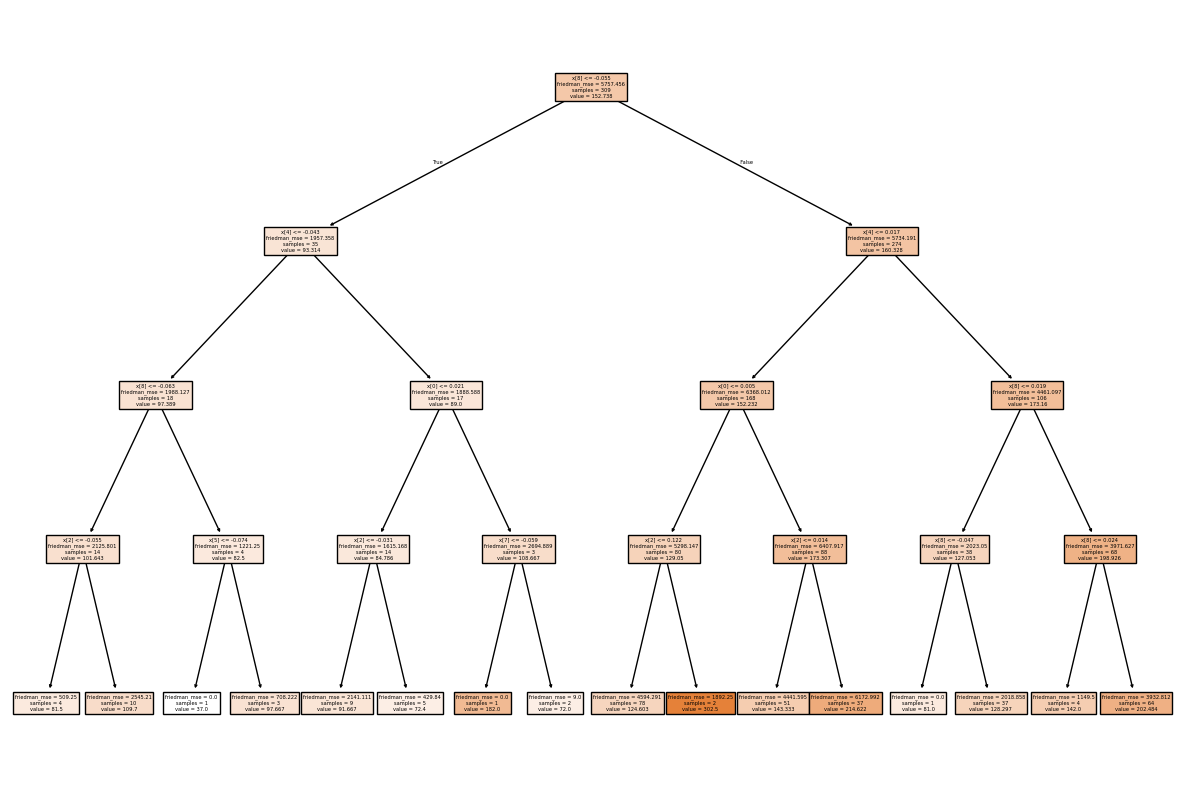

In [18]:
##Visualize the Decision Tree
import matplotlib.pyplot as plt
from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(selectedmodel,filled=True)